In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [5]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
54,857438,M,15.10,22.02,97.26,712.8,0.09056,0.07081,0.052530,0.033340,...,31.69,117.70,1030.0,0.13890,0.20570,0.271200,0.15300,0.2675,0.07873,NaN
109,864018,B,11.34,21.26,72.48,396.5,0.08759,0.06575,0.051330,0.018990,...,29.15,83.99,518.1,0.16990,0.21960,0.312000,0.08278,0.2829,0.08832,NaN
157,8711216,B,16.84,19.46,108.40,880.2,0.07445,0.07223,0.051500,0.027710,...,28.07,120.30,1032.0,0.08774,0.17100,0.188200,0.08436,0.2527,0.05972,NaN
332,897132,B,11.22,19.86,71.94,387.3,0.10540,0.06779,0.005006,0.007583,...,25.78,76.91,436.1,0.14240,0.09669,0.013350,0.02022,0.3292,0.06522,NaN
327,895299,B,12.03,17.93,76.09,446.0,0.07683,0.03892,0.001546,0.005592,...,22.25,82.74,523.4,0.10130,0.07390,0.007732,0.02796,0.2171,0.07037,NaN


In [6]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(569, 33)


In [7]:
print("Total Rows =", df.shape[0])

Total Rows = 569


In [8]:
print("Total Columns =", df.shape[1])

Total Columns = 33


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [11]:
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [12]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [13]:
df.describe(include="all")

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN


In [14]:
numerical_features = df.select_dtypes(include=np.number).columns

print("Numerical Features:")

print(numerical_features)

Numerical Features:
Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [15]:
print("Target Variable")

print(df["diagnosis"].head())

Target Variable
0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object


In [16]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


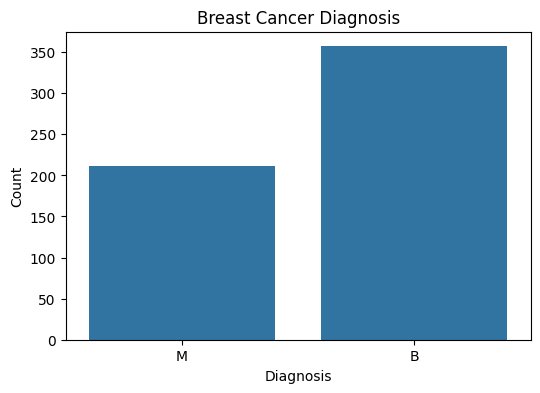

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="diagnosis", data=df)

plt.title("Breast Cancer Diagnosis")

plt.xlabel("Diagnosis")

plt.ylabel("Count")

plt.show()

In [18]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [19]:
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

In [20]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
print(df.shape)

(569, 31)


In [22]:
encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

In [23]:
df["diagnosis"].head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [24]:
print(encoder.classes_)

['B' 'M']


In [25]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [26]:
print("Shape of X")

print(X.shape)

Shape of X
(569, 30)


In [27]:
print("Shape of y")

print(y.shape)

Shape of y
(569,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
print("Training Feature Shape :", X_train.shape)

print("Training Target Shape :", y_train.shape)

Training Feature Shape : (455, 30)
Training Target Shape : (455,)


In [30]:
print("Testing Feature Shape :", X_test.shape)

print("Testing Target Shape :", y_test.shape)

Testing Feature Shape : (114, 30)
Testing Target Shape : (114,)


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
print(X_train[:5])

[[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.12095781 -0.35077918  0.57276579  0.7394992   0.32065553  0.58946222
   2.61504052  0.71892779 -1.29528358

In [33]:
print(X_test[:5])

[[-4.66497433e-01 -1.37289334e-01 -4.44211377e-01 -4.86464982e-01
   2.80850072e-01  4.16058881e-02 -1.11464957e-01 -2.64868656e-01
   4.15241410e-01  1.35137436e-01 -2.09150908e-02 -2.93239068e-01
  -1.74608693e-01 -2.07299502e-01 -1.18143232e-02 -3.51089212e-01
  -1.81053500e-01 -2.42388306e-01 -3.37317581e-01 -8.42132958e-02
  -2.63235395e-01 -1.47842078e-01 -3.31547522e-01 -3.51093371e-01
   4.80019421e-01 -9.64959374e-02 -3.58304052e-02 -1.94350872e-01
   1.72756689e-01  2.03729954e-01]
 [ 1.36536344e+00  4.98664735e-01  1.30551088e+00  1.34147086e+00
  -4.06539021e-01 -1.37241019e-02  2.40636589e-01  8.21448757e-01
  -8.33980787e-01 -1.13121527e+00  1.36745547e+00 -7.48749068e-01
   1.27009847e+00  1.18638199e+00 -8.33501438e-01 -4.90439186e-01
  -3.15589998e-01  2.87260309e-01 -8.22435343e-01 -7.62357471e-01
   1.79461875e+00  1.72372385e-01  1.76366112e+00  1.74414120e+00
  -5.30514169e-01 -1.23620037e-01 -2.81810465e-02  9.91778617e-01
  -5.61211002e-01 -1.00838949e+00]
 [ 3.8

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

In [35]:
knn

KNeighborsClassifier()

In [36]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [37]:
y_pred = knn.predict(X_test)

In [38]:
print(y_pred)

[0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]


In [39]:
print(y_test.values)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]


In [40]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,0,1
9,0,0


In [41]:
correct_predictions = (y_test.values == y_pred).sum()

print("Correct Predictions :", correct_predictions)

Correct Predictions : 108


In [42]:
incorrect_predictions = (y_test.values != y_pred).sum()

print("Incorrect Predictions :", incorrect_predictions)

Incorrect Predictions : 6


In [43]:
print("Total Predictions :", len(y_pred))

Total Predictions : 114


In [44]:
train_prediction = knn.predict(X_train)

print(train_prediction[:20])

[0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0]


In [45]:
comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,0,1
9,0,0


In [46]:
print("Number of Neighbors :", knn.n_neighbors)

Number of Neighbors : 5


In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.9473684210526315


In [48]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.9302325581395349


In [49]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.9302325581395349


In [50]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.9302325581395349


In [51]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68  3]
 [ 3 40]]


In [52]:
results = pd.DataFrame({

    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],

    "Value": [accuracy, precision, recall, f1]

})

results

,Metric,Value
0,Accuracy,0.947368
1,Precision,0.930233
2,Recall,0.930233
3,F1 Score,0.930233


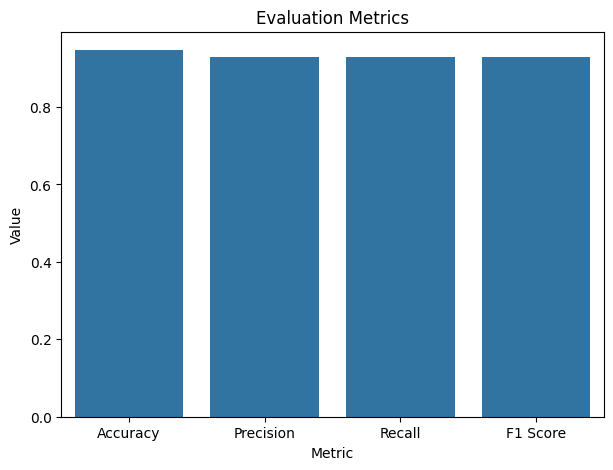

In [53]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Metric",
    y="Value",
    data=results
)

plt.title("Evaluation Metrics")

plt.show()

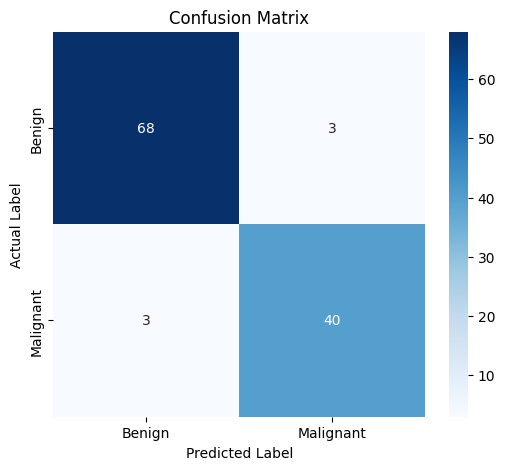

In [54]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix")

plt.show()

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [56]:
print("Accuracy Score :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy Score : 0.9473684210526315
Precision : 0.9302325581395349
Recall : 0.9302325581395349
F1 Score : 0.9302325581395349


In [57]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,0,1
9,0,0


## Observations

### Observation 1

The KNN classifier achieved a high Accuracy Score, indicating that it correctly classified most breast tumor samples.

### Observation 2

The Precision, Recall, and F1 Score values are high, showing that the model performs well in identifying both Benign and Malignant tumors.

### Observation 3

The Confusion Matrix indicates that only a small number of samples were misclassified, demonstrating that KNN is an effective classifier for this dataset.



## Conclusion

In this project, a K-Nearest Neighbors (KNN) classification model was developed to classify breast tumors as Malignant or Benign using the Breast Cancer Wisconsin Diagnostic Dataset. The dataset was explored, cleaned by removing unnecessary columns, and the target variable was encoded into numerical values. Since KNN is a distance-based algorithm, feature scaling was performed using StandardScaler before training the model. The trained model achieved high Accuracy, Precision, Recall, and F1-Score, indicating reliable classification performance. Compared to many basic classification methods, KNN effectively classified tumors based on the similarity between data points. However, one limitation of KNN is that its prediction time increases with larger datasets because it calculates distances to all training samples. Overall, KNN proved to be an effective algorithm for breast cancer classification.

# Key Findings

- The Breast Cancer Wisconsin Diagnostic Dataset contains diagnostic measurements of breast tumors.
- The KNN classifier successfully classified tumors into Benign and Malignant categories.
- Feature scaling significantly improved the model's performance.
- The model achieved high Accuracy, Precision, Recall, and F1-Score.
- The Confusion Matrix showed that only a small number of samples were misclassified.

# Importance of Feature Scaling in KNN

K-Nearest Neighbors (KNN) is a distance-based machine learning algorithm that calculates the distance between data points. If the features have different scales, features with larger values dominate the distance calculation and reduce the model's accuracy. Standardizing the features ensures that all variables contribute equally during distance computation, resulting in better classification performance and more reliable predictions.

# Limitation of K-Nearest Neighbors (KNN)

One major limitation of the KNN algorithm is that it becomes computationally expensive for large datasets because it must calculate the distance between the test sample and every training sample. As the dataset size increases, prediction becomes slower and requires more memory.